**MC859**  
Alícia Gonçalves Vieira (RA: 219950) | Lucca Pavanatti Duarte (RA: 230555)

---

## 1. Instalação de dependências

In [ ]:
!pip install networkx matplotlib numpy tqdm --quiet

## 2. Coleta de dados

In [ ]:
import os
import urllib.request
import gzip
import shutil

DATA_URL  = "https://snap.stanford.edu/data/bigdata/amazon/amazon-meta.txt.gz"
GZ_FILE   = "amazon-meta.txt.gz"
DATA_FILE = "amazon-meta.txt"

if not os.path.exists(DATA_FILE):
    if not os.path.exists(GZ_FILE):
        urllib.request.urlretrieve(DATA_URL, GZ_FILE)
    with gzip.open(GZ_FILE, 'rb') as f_in, open(DATA_FILE, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

print(f"Tamanho do arquivo: {os.path.getsize(DATA_FILE) / 1e6:.1f} MB")

Tamanho do arquivo: 977.5 MB


## 3. Parsing do dataset

In [ ]:
import re

def parse_amazon_meta(filepath):
    nodes       = {}
    similar_raw = {}
    current     = {}

    def commit(p):
        asin = p.get('asin')
        if not asin or p.get('discontinued'):
            return
        nodes[asin] = {
            'title':      p.get('title', ''),
            'group':      p.get('group', ''),
            'salesrank':  p.get('salesrank', -1),
            'avg_rating': p.get('avg_rating', 0.0),
            'reviews':    p.get('reviews', 0),
        }
        similar_raw[asin] = p.get('similar', [])

    with open(filepath, 'r', encoding='latin-1') as f:
        for raw_line in f:
            line = raw_line.strip()

            if line.startswith('Id:'):
                if current:
                    commit(current)
                current = {}

            elif line.startswith('ASIN:'):
                current['asin'] = line.split(':', 1)[1].strip()

            elif line.startswith('discontinued product'):
                current['discontinued'] = True

            elif line.startswith('title:'):
                current['title'] = line.split(':', 1)[1].strip()

            elif line.startswith('group:'):
                current['group'] = line.split(':', 1)[1].strip()

            elif line.startswith('salesrank:'):
                try:
                    current['salesrank'] = int(line.split(':', 1)[1].strip())
                except ValueError:
                    current['salesrank'] = -1

            elif line.startswith('similar:'):
                parts = line.split()
                if len(parts) >= 3:
                    current['similar'] = parts[2:]

            elif line.startswith('reviews:'):
                m = re.search(r'avg rating:\s*([\d.]+)', line)
                if m:
                    current['avg_rating'] = float(m.group(1))
                m2 = re.search(r'total:\s*(\d+)', line)
                if m2:
                    current['reviews'] = int(m2.group(1))

        if current:
            commit(current)

    return nodes, similar_raw

nodes, similar_raw = parse_amazon_meta(DATA_FILE)

---
## 4. Instância 1 — Grafo Original de Co-compra

In [ ]:
import networkx as nx

valid = set(nodes.keys())

G_orig = nx.Graph(name="amazon_original")

for asin, attrs in nodes.items():
    G_orig.add_node(asin, **attrs)

discarded = 0
for u, neighbors in similar_raw.items():
    for v in neighbors:
        if v in valid and u != v:
            G_orig.add_edge(u, v)
        else:
            discarded += 1

print("Grafo Original construido:")
print(f"  Nos    : {G_orig.number_of_nodes():,}")
print(f"  Arestas: {G_orig.number_of_edges():,}")
print(f"  Arestas descartadas (ASIN invalido): {discarded:,}")

Grafo Original construido:
  Nos    : 542,684
  Arestas: 987,903
  Arestas descartadas (ASIN invalido): 557,325


---
## 5. Instância 2 — Grafo Ponderado por Similaridade de Jaccard

In [ ]:
S = {u: set(G_orig.neighbors(u)) for u in G_orig.nodes()}

print(f"Conjuntos S(u) construidos para {len(S):,} nos.")
print(f"Total de entradas: {sum(len(v) for v in S.values()):,}")

Conjuntos S(u) construidos para 542,684 nos.
Total de entradas: 1,975,806


In [ ]:
from itertools import combinations
from tqdm import tqdm

THETA = 0.1
HUB_CAP = 200

candidate_pairs = set()

for w in tqdm(G_orig.nodes(), total=G_orig.number_of_nodes(), mininterval=2.0):
    block = list(S[w])
    if len(block) > HUB_CAP:
        block = block[:HUB_CAP]
    for u, v in combinations(block, 2):
        candidate_pairs.add((u, v) if u < v else (v, u))

n_total_pairs = G_orig.number_of_nodes() * (G_orig.number_of_nodes() - 1) // 2
print()
print(f"Pares candidatos apos blocking : {len(candidate_pairs):,}")
print(f"Pares totais possiveis (n*(n-1)/2): {n_total_pairs:,}")
print(f"Reducao                          : {100*(1 - len(candidate_pairs)/n_total_pairs):.4f}% dos pares eliminados")

100%|██████████| 542684/542684 [00:08<00:00, 63937.97it/s]


Pares candidatos apos blocking : 6,662,203
Pares totais possiveis (n*(n-1)/2): 147,252,690,586
Reducao                          : 99.9955% dos pares eliminados


In [ ]:
G_jacc = nx.Graph(name="amazon_jaccard")

for asin, attrs in nodes.items():
    G_jacc.add_node(asin, **attrs)

edges_added    = 0
edges_skipped  = 0
all_jaccard_values = []

for u, v in tqdm(candidate_pairs, mininterval=2.0):
    Su = S.get(u)
    Sv = S.get(v)
    if not Su or not Sv:
        continue
    inter = len(Su & Sv)
    if inter == 0:
        edges_skipped += 1
        continue
    j = inter / len(Su | Sv)
    all_jaccard_values.append(j)
    if j >= THETA:
        G_jacc.add_edge(u, v, weight=round(j, 6))
        edges_added += 1
    else:
        edges_skipped += 1

print(f"\nGrafo Jaccard (theta = {THETA}):")
print(f"  Nos    : {G_jacc.number_of_nodes():,}")
print(f"  Arestas: {G_jacc.number_of_edges():,}")
print(f"  Pares descartados (J=0 ou J<theta): {edges_skipped:,}")

100%|██████████| 6662203/6662203 [01:07<00:00, 99019.14it/s]



Grafo Jaccard (theta = 0.1):
  Nos    : 542,684
  Arestas: 4,403,036
  Pares descartados (J=0 ou J<theta): 2,259,167


### 5.1 Analise da escolha do limiar θ

 theta    Arestas mantidas     % dos pares com J>0
----------------------------------------------------
  0.05           5,848,343                  87.78%
  0.10           4,403,036                  66.09%
  0.15           2,296,424                  34.47%
  0.20           1,687,597                  25.33%
  0.30             713,157                  10.70%
  0.50             266,279                   4.00%


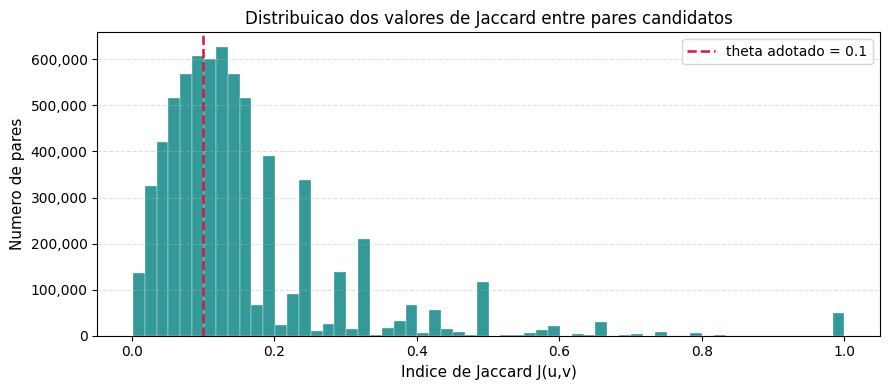

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

jvals = np.array(all_jaccard_values)

thresholds = [0.05, 0.10, 0.15, 0.20, 0.30, 0.50]
print(f"{'theta':>6}  {'Arestas mantidas':>18}  {'% dos pares com J>0':>22}")
print("-" * 52)
for t in thresholds:
    n = int((jvals >= t).sum())
    pct = 100 * n / len(jvals) if len(jvals) > 0 else 0
    print(f"{t:>6.2f}  {n:>18,}  {pct:>21.2f}%")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(jvals, bins=60, color='teal', alpha=0.8, edgecolor='white', linewidth=0.3)
ax.axvline(THETA, color='crimson', linestyle='--', linewidth=1.8,
           label=f'theta adotado = {THETA}')
ax.set_xlabel("Indice de Jaccard J(u,v)", fontsize=11)
ax.set_ylabel("Numero de pares", fontsize=11)
ax.set_title("Distribuicao dos valores de Jaccard entre pares candidatos", fontsize=12)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("jaccard_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Exportacao dos grafos

In [ ]:
FILES = [
    (G_orig, "amazon_original"),
    (G_jacc, "amazon_jaccard"),
]

for G, name in FILES:
    graphml_path = f"{name}.graphml"
    nx.write_graphml(G, graphml_path)
    sz_m = os.path.getsize(graphml_path) / 1e6
    print(f"{name}:")
    print(f"  {graphml_path:<40} {sz_m:.1f} MB")

amazon_original:
  amazon_original.graphml                  164.0 MB
amazon_jaccard:
  amazon_jaccard.graphml                   495.9 MB


---
## 7. Analise Inicial

### 7.1 Tamanho dos grafos: vertices, arestas e grau medio

In [ ]:
from collections import Counter

def graph_summary(G, label):
    n   = G.number_of_nodes()
    m   = G.number_of_edges()
    avg = (2 * m) / n if n > 0 else 0
    degs = [d for _, d in G.degree()]
    print(f"\n{'='*52}")
    print(f"  {label}")
    print(f"{'='*52}")
    print(f"  Número de vertices  : {n:>14,}")
    print(f"  Nuúero de arestas   : {m:>14,}")
    print(f"  Grau médio          : {avg:>14.4f}")
    print(f"  Grau maximo         : {max(degs):>14,}")
    print(f"  Nós isolados (k=0)  : {degs.count(0):>14,}")
    return degs

degs_orig = graph_summary(G_orig, "Grafo Original (co-compra direta)")
degs_jacc = graph_summary(G_jacc, f"Grafo Jaccard (theta = {THETA})")


  Grafo Original (co-compra direta)
  Número de vertices  :        542,684
  Nuúero de arestas   :        987,903
  Grau médio          :         3.6408
  Grau maximo         :            549
  Nós isolados (k=0)  :        175,697

  Grafo Jaccard (theta = 0.1)
  Número de vertices  :        542,684
  Nuúero de arestas   :      4,403,036
  Grau médio          :        16.2269
  Grau maximo         :            460
  Nós isolados (k=0)  :        182,745


### 7.2 Distribuicao dos graus — ambos os grafos

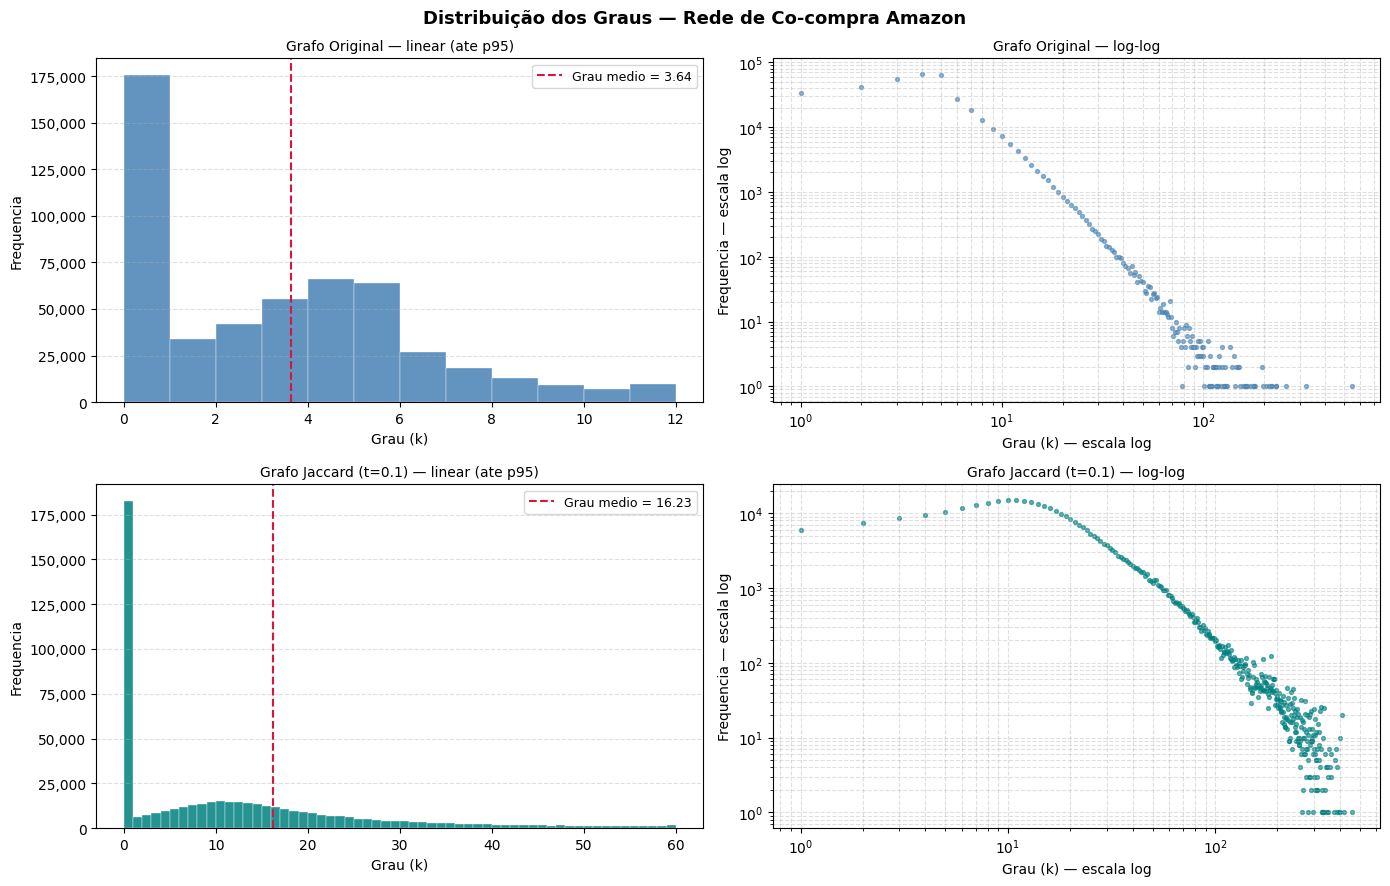

In [ ]:
def plot_degree_dist(degs, title, color, ax_lin, ax_log):
    cnt = Counter(degs)
    p95 = int(np.percentile(degs, 95))

    ax_lin.hist(degs, bins=range(0, p95 + 2), color=color,
                edgecolor='white', linewidth=0.3, alpha=0.85)
    ax_lin.axvline(np.mean(degs), color='crimson', linestyle='--', linewidth=1.5,
                   label=f'Grau medio = {np.mean(degs):.2f}')
    ax_lin.set_title(f"{title} — linear (ate p95)", fontsize=10)
    ax_lin.set_xlabel("Grau (k)")
    ax_lin.set_ylabel("Frequencia")
    ax_lin.legend(fontsize=9)
    ax_lin.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax_lin.grid(axis='y', linestyle='--', alpha=0.4)

    pos_k = sorted(k for k in cnt if k > 0)
    pos_f = [cnt[k] for k in pos_k]
    ax_log.scatter(pos_k, pos_f, s=8, color=color, alpha=0.6)
    ax_log.set_xscale('log')
    ax_log.set_yscale('log')
    ax_log.set_title(f"{title} — log-log", fontsize=10)
    ax_log.set_xlabel("Grau (k) — escala log")
    ax_log.set_ylabel("Frequencia — escala log")
    ax_log.grid(True, which='both', linestyle='--', alpha=0.4)


fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Distribuição dos Graus — Rede de Co-compra Amazon",
             fontsize=13, fontweight='bold')

plot_degree_dist(degs_orig, "Grafo Original",           'steelblue', axes[0][0], axes[0][1])
plot_degree_dist(degs_jacc, f"Grafo Jaccard (t={THETA})", 'teal',    axes[1][0], axes[1][1])

plt.tight_layout()
plt.savefig("degree_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

### 7.3 Componentes conexas

In [ ]:
def component_analysis(G, label):
    comps = sorted(nx.connected_components(G), key=len, reverse=True)
    sizes = [len(c) for c in comps]
    n     = G.number_of_nodes()
    print(f"\n{'='*54}")
    print(f"  {label}")
    print(f"{'='*54}")
    print(f"  Numero de componentes conexas  : {len(comps):,}")
    print(f"  Maior componente (vertices)    : {sizes[0]:,}  ({100*sizes[0]/n:.2f}%)")
    if len(sizes) > 1:
        print(f"  2a maior componente            : {sizes[1]:,}")
    print(f"  Componentes com 1 vertice      : {sum(1 for s in sizes if s == 1):,}")
    return sizes

sizes_orig = component_analysis(G_orig, "Grafo Original")
sizes_jacc = component_analysis(G_jacc, f"Grafo Jaccard (theta = {THETA})")


  Grafo Original
  Numero de componentes conexas  : 181,706
  Maior componente (vertices)    : 334,852  (61.70%)
  2a maior componente            : 222
  Componentes com 1 vertice      : 175,697

  Grafo Jaccard (theta = 0.1)
  Numero de componentes conexas  : 186,719
  Maior componente (vertices)    : 332,573  (61.28%)
  2a maior componente            : 221
  Componentes com 1 vertice      : 182,745


### 7.4 Distribuicao dos tamanhos das componentes


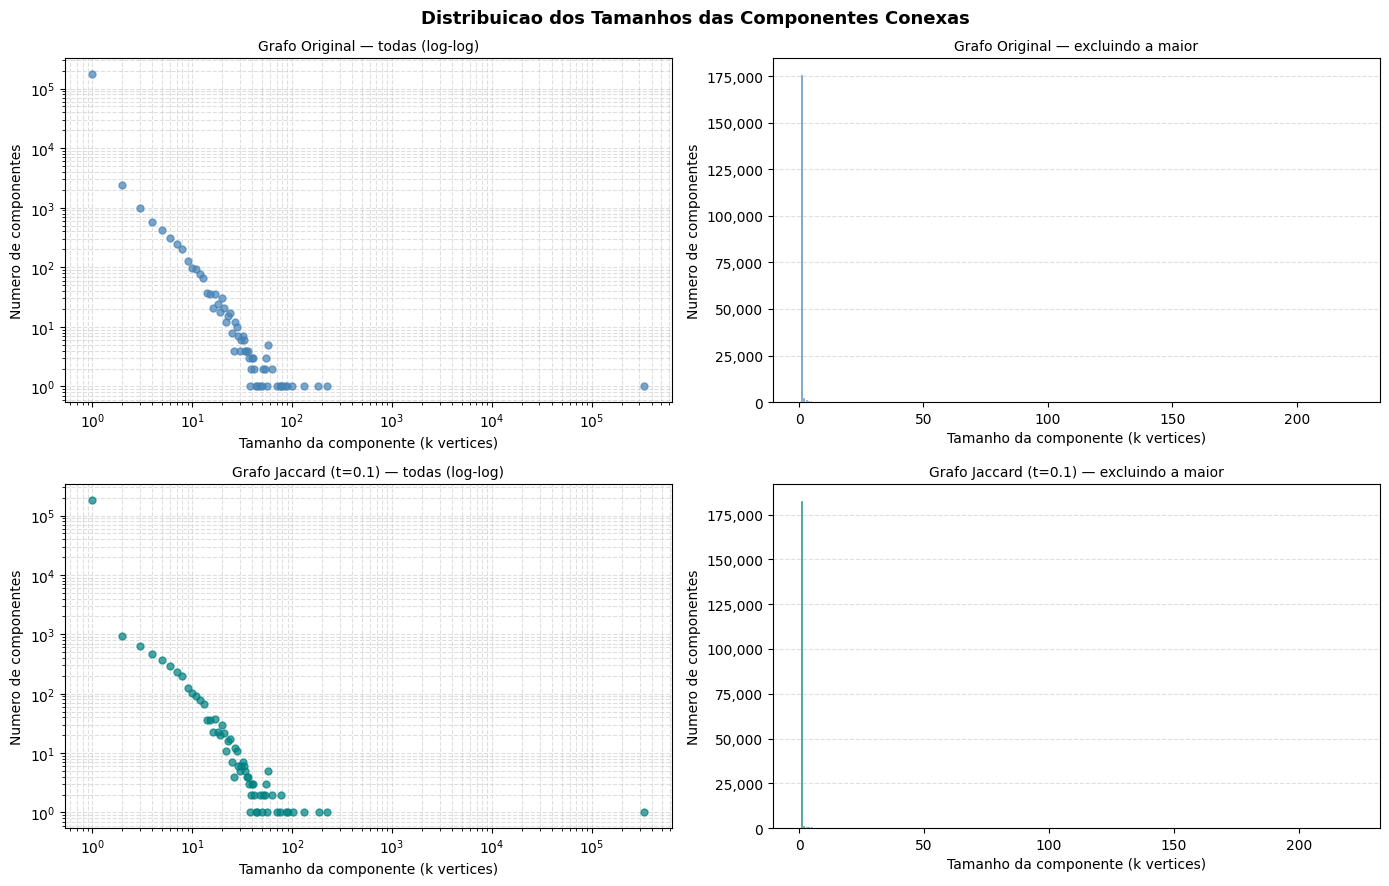

In [ ]:
def plot_component_dist(sizes, title, color, axes_row):
    cnt = Counter(sizes)
    sk  = sorted(cnt.keys())
    sc  = [cnt[k] for k in sk]
    ax_log, ax_bar = axes_row

    ax_log.scatter(sk, sc, s=25, color=color, alpha=0.7, zorder=3)
    ax_log.set_xscale('log')
    ax_log.set_yscale('log')
    ax_log.set_xlabel("Tamanho da componente (k vertices)")
    ax_log.set_ylabel("Numero de componentes")
    ax_log.set_title(f"{title} — todas (log-log)", fontsize=10)
    ax_log.grid(True, which='both', linestyle='--', alpha=0.4)

    small = [s for s in sizes if s < sizes[0]]
    if small:
        sm_cnt = Counter(small)
        ssk    = sorted(sm_cnt.keys())
        ssc    = [sm_cnt[k] for k in ssk]
        ax_bar.bar(ssk, ssc, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
        ax_bar.set_xlabel("Tamanho da componente (k vertices)")
        ax_bar.set_ylabel("Numero de componentes")
        ax_bar.set_title(f"{title} — excluindo a maior", fontsize=10)
        ax_bar.yaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
        ax_bar.grid(axis='y', linestyle='--', alpha=0.4)
    else:
        ax_bar.text(0.5, 0.5, "Apenas uma componente",
                    ha='center', va='center',
                    transform=ax_bar.transAxes, fontsize=12)
        ax_bar.set_axis_off()


fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Distribuicao dos Tamanhos das Componentes Conexas",
             fontsize=13, fontweight='bold')

plot_component_dist(sizes_orig, "Grafo Original",             'steelblue', axes[0])
plot_component_dist(sizes_jacc, f"Grafo Jaccard (t={THETA})", 'teal',      axes[1])

plt.tight_layout()
plt.savefig("component_distribution.png", dpi=150, bbox_inches='tight')
plt.show()